In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    log_loss,
    brier_score_loss,
)
import seaborn as sns

#Load the dataset
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

#Features
X = [
    "rank_diff",
    "rank_points_diff",
    "elo_diff",
    "age_diff",
    "selo_diff",
    "comp_diff",
    "serv_diff",
    "form_diff",
]

#Target
y = "result"

#Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []
best_params_list = []
cv_monitor = []
row_ids = []
coef_records = []

#Rolling setup
WINDOW_SIZE = 10000   #4 years of data
STEP = 100

LOGIT = LogisticRegression(
    max_iter=5000,
    random_state=1
)

pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LOGIT),
])

#Hyperparameter C grid
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10]
}

#Rolling window forecast loop
for i in range(WINDOW_SIZE, len(df), STEP):
    train_data = df.iloc[i-WINDOW_SIZE:i]
    test_data = df.iloc[i:i+STEP]

    if len(test_data) == 0:
        break

    X_train = train_data[X]
    y_train = train_data[y]
    X_test = test_data[X]
    y_test = test_data[y]

    tscv = TimeSeriesSplit(n_splits=2)

    search = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=tscv,
        n_jobs=-1,
        scoring="neg_log_loss",
        refit=True,
        return_train_score=True
    )

    search.fit(X_train, y_train)
    
    #Barplot
    best_model = search.best_estimator_
    coefs = best_model.named_steps["clf"].coef_[0]

    for feature, coef in zip(X, coefs):
        coef_records.append({
        "Feature": feature,
        "Coefficient": coef
    })
        
    #CV monitoring
    res = pd.DataFrame(search.cv_results_)
    best_row = res.iloc[search.best_index_]

    cv_monitor.append({
        "Index": i,
        "Date": test_data["tourney_date"].iloc[0],
        "Best_Params": search.best_params_,
        "Mean_Train_Score": float(best_row["mean_train_score"]),
        "Mean_Valid_Score": float(best_row["mean_test_score"]),
    })

    #Store predictions
    best_params_list.append(search.best_params_)
    dates.extend(test_data["tourney_date"].tolist())

    preds = search.predict(X_test)
    probs = search.predict_proba(X_test)[:, 1]

    predictions.extend(preds)
    probabilities.extend(probs)
    actuals.extend(y_test.tolist())
    row_ids.extend(test_data.index.tolist())
    
coef_df = pd.DataFrame(coef_records)

coef_summary = (
    coef_df
    .groupby("Feature")["Coefficient"]
    .mean()
    .reindex(X)
    .reset_index()
)

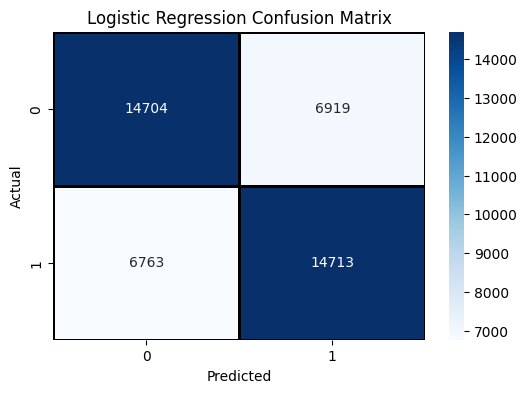

Accuracy: 0.683
Log Loss: 0.588
Brier Score: 0.202


In [2]:
#Confusion matrix
cm = confusion_matrix(actuals, predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor='black')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("logit_confusion_matrix.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()

#Accuracy
accuracy = accuracy_score(actuals, predictions)
print(f"Accuracy: {accuracy:.3f}")

#Log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")


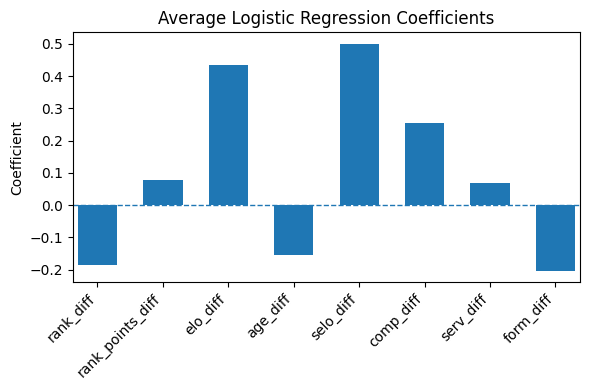

In [ ]:
#Logistic regression coefficients bar plot
plt.figure(figsize=(6, 4))

plt.bar(
    coef_summary["Feature"],
    coef_summary["Coefficient"],
    width=0.6
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Average Logistic Regression Coefficients")
plt.ylabel("Coefficient")
plt.xticks(rotation=45, ha="right")

plt.margins(x=0.01)
plt.tight_layout()
plt.savefig("logit_coefficients.pdf", bbox_inches="tight", pad_inches=0.02)
plt.show()